In [14]:
# Libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data load
train_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')

print("Train Data:")
display(train_data.head())

#Column & Data type
print("\nData Info:")
print(train_data.info())

Train Data:


,Id,title,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
0,1,My Happiness,Connie Francis,adult standards,1996,107,31,45,-8,13,28,150,75,3,44
1,2,Unchained Melody,The Teddy Bears,NaN,2011,114,44,53,-8,13,47,139,49,3,37
2,3,How Deep Is Your Love,Bee Gees,adult standards,1979,105,36,63,-9,13,67,245,11,3,77
3,4,Woman in Love,Barbra Streisand,adult standards,1980,170,28,47,-16,13,33,232,25,3,67
4,5,Goodbye Yellow Brick Road - Remastered 2014,Elton John,glam rock,1973,121,47,56,-8,15,40,193,45,3,63



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         453 non-null    int64 
 1   title      453 non-null    object
 2   artist     453 non-null    object
 3   top genre  438 non-null    object
 4   year       453 non-null    int64 
 5   bpm        453 non-null    int64 
 6   nrgy       453 non-null    int64 
 7   dnce       453 non-null    int64 
 8   dB         453 non-null    int64 
 9   live       453 non-null    int64 
 10  val        453 non-null    int64 
 11  dur        453 non-null    int64 
 12  acous      453 non-null    int64 
 13  spch       453 non-null    int64 
 14  pop        453 non-null    int64 
dtypes: int64(12), object(3)
memory usage: 53.2+ KB
None


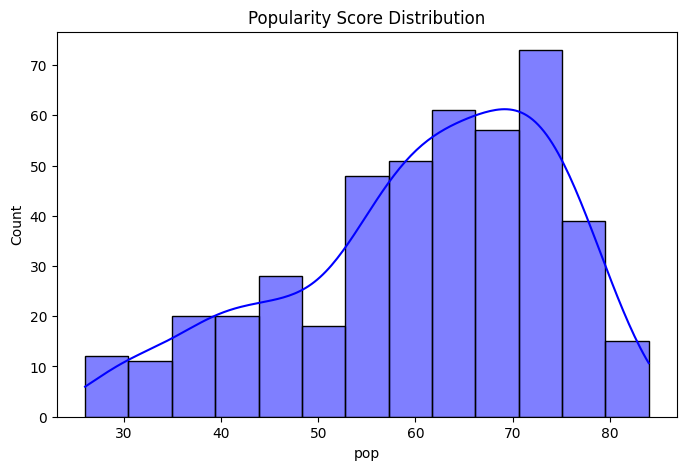


Total Unique Genres: 86

Top 10 Genres:
top genre
adult standards       68
album rock            66
dance pop             61
glam rock             16
brill building pop    16
europop               14
dance rock            13
boy band              10
british invasion       8
bubblegum dance        7
Name: count, dtype: int64


In [17]:
# 1. Popularity
plt.figure(figsize=(8,5))
sns.histplot(train_data['pop'], kde=True, color='blue')
plt.title('Popularity Score Distribution')
plt.show()

# 2. Genre
print("\nTotal Unique Genres:", train_data['top genre'].nunique())
print("\nTop 10 Genres:")
print(train_data['top genre'].value_counts().head(10))


Train Data:


,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
0,56,1,1996,107,31,45,-8,13,28,150,75,3,44
1,306,77,2011,114,44,53,-8,13,47,139,49,3,37
2,20,1,1979,105,36,63,-9,13,67,245,11,3,77
3,19,1,1980,170,28,47,-16,13,33,232,25,3,67
4,94,68,1973,121,47,56,-8,15,40,193,45,3,63



Test Data:


,artist,top genre,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch
0,82,20,2005,154,93,65,-3,75,74,213,1,18
1,34,31,1994,161,39,30,-15,11,14,292,26,3
2,68,31,1977,64,46,27,-7,12,18,179,38,3
3,38,8,2010,127,92,71,-9,37,53,216,6,4
4,47,4,2018,115,46,56,-12,21,34,153,18,3


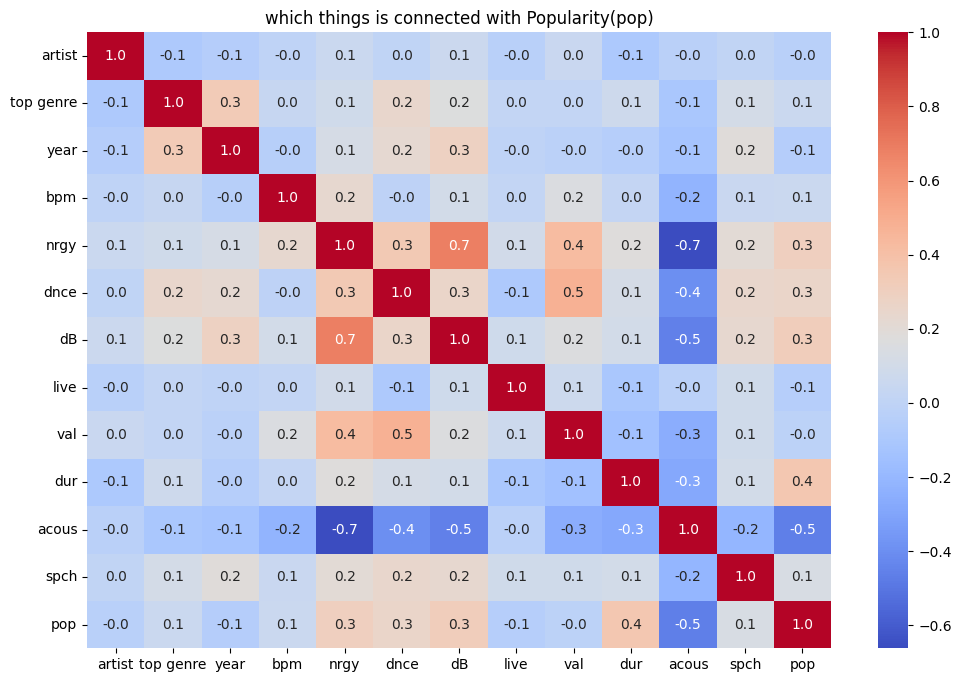

In [26]:
from sklearn.preprocessing import LabelEncoder

# 1. Original data copy (safe side)
df_train = train_data.copy()
df_test = test_data.copy()

# 2. Text column
le = LabelEncoder()

# Train data convert
df_train['artist'] = le.fit_transform(df_train['artist'].astype(str))
df_train['top genre'] = le.fit_transform(df_train['top genre'].astype(str))

# Test data convert
df_test['artist'] = le.fit_transform(df_test['artist'].astype(str))
df_test['top genre'] = le.fit_transform(df_test['top genre'].astype(str))

# Unusable column remove for not helping (ID & Title) predict
df_train.drop(['Id', 'title'], axis=1, inplace=True)
df_test.drop(['Id', 'title'], axis=1, inplace=True) # also remove from test

print("\nTrain Data:")
display(df_train.head())

print("\nTest Data:")
display(df_test.head())


# 4. Correlation Materix (that's show which is important or not)
plt.figure(figsize=(12,8))
sns.heatmap(df_train.corr(), annot=True, cmap='coolwarm', fmt='.1f')
plt.title('which things is connected with Popularity(pop)')
plt.show()


In [27]:
from re import X
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Target: Target (y) & Features (X) are seperated
X = df_train.drop('pop', axis=1)

# Everything seemed except 'pop'
y = df_train['pop']

# only seemed 'pop' (Target)

# 2. Training start ( Computer is learning)
# we are breaking the data: 80% for learning, 20% for testing

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 3. Check how much learning(prediction)
predictions = model.predict(X_val)

# Score check (RMSE - Less more works better)
mse = mean_squared_error(y_val, predictions)
rmse = mse ** 0.5

print(f"My Model Error (RMSE): {rmse}")
print("\nPredicted vs Actual (first 5 values):")
comparision = pd.DataFrame({'Actul': y_val[:5], 'Predicted': predictions[:5]})
display(comparision)

My Model Error (RMSE): 12.31436056993119

Predicted vs Actual (first 5 values):


,Actul,Predicted
352,47,54.397352
39,63,70.048895
361,73,70.285001
358,74,64.747752
154,71,63.506627


In [35]:
# 1. Actual Test Data prediction start
final_predictions = model.predict(df_test)

# 2. Submission file create
# (Whose kaggle be Demad)
submission = pd.DataFrame({
       'Id': test_data['Id'], # Id is important for kaggle verify, using original test_data for 'Id'
       'pop': final_predictions # My predictions
})

# 3. CSV file save
submission.to_csv('submission_linear.csv', index=False)

print("Congrats!\n'submission_linear.csv' created.")
print("Left side folder refresh and check.")

Congrats!
'submission_linear.csv' created.
Left side folder refresh and check.


In [36]:
from sklearn.ensemble import RandomForestRegressor

# 1. Random Forest Model Create
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Score Check (for Validation data)
val_predictions = rf_model.predict(X_val)
rf_rmse = mean_squared_error(y_val, val_predictions) ** 0.5
print(f"My New Score (Random Forest RMSE): {rf_rmse}")

# 3. File Create for Kaggle
final_rf_pred = rf_model.predict(df_test_clean)

submission_rf = pd.DataFrame({
       'Id': test_data['Id'],
       'pop': final_rf_pred
})
submission_rf.to_csv('submission_rf.csv', index=False)
print("submission_rf.csv has been created!")

My New Score (Random Forest RMSE): 10.913981304367711
submission_rf.csv has been created!
